In [2]:
import sys
import collections

try:
    import graphviz
except ImportError:
    print("Graphviz library not found. Installing...")
    !{sys.executable} -m pip install graphviz
    import graphviz

class Graph:
    def __init__(self, directed=False):
        self.graph = collections.defaultdict(list)
        self.directed = directed

    def add_edge(self, u, v):
        self.graph[u].append(v)
        if not self.directed:
            self.graph[v].append(u)

    def get_neighbors(self, u):
        return self.graph[u]

    def display(self):
        print("Adjacency List Graph Jawa Tengah:")
        for node in sorted(self.graph.keys()):
            print(f"  {node}: {sorted(self.graph[node])}")


jateng_graph = Graph(directed=False)

edges_jateng = [
    ('Brebes', 'Tegal'),
    ('Tegal', 'Pemalang'),
    ('Pemalang', 'Pekalongan'),
    ('Pekalongan', 'Kendal'),
    ('Kendal', 'Semarang'),
    ('Semarang', 'Demak'),
    ('Demak', 'Kudus'),
    ('Kudus', 'Rembang'),
    ('Rembang', 'Blora'),
    ('Brebes', 'Slawi'),
    ('Tegal', 'Slawi'),
    ('Slawi', 'Purwokerto'),

    ('Purwokerto', 'Cilacap'),
    ('Purwokerto', 'Kroya'),
    ('Cilacap', 'Kroya'),
    ('Kroya', 'Kebumen'),
    ('Kebumen', 'Purworejo'),
    ('Purworejo', 'Magelang'),

    ('Pemalang', 'Purbalingga'),
    ('Purwokerto', 'Purbalingga'),
    ('Purbalingga', 'Banjarnegara'),
    ('Banjarnegara', 'Wonosobo'),
    ('Wonosobo', 'Temanggung'),
    ('Temanggung', 'Kendal'),
    ('Temanggung', 'Salatiga'),
    ('Temanggung', 'Magelang'),

    ('Semarang', 'Salatiga'),
    ('Salatiga', 'Boyolali'),
    ('Magelang', 'Boyolali'),
    ('Magelang', 'Wonosobo'),
    ('Boyolali', 'Klaten'),
    ('Boyolali', 'Solo'),

    ('Solo', 'Sukoharjo'),
    ('Solo', 'Sragen'),
    ('Solo', 'Purwodadi'),
    ('Sukoharjo', 'Wonogiri'),
    ('Sragen', 'Blora'),
    ('Purwodadi', 'Demak'),
    ('Purwodadi', 'Kudus'),
    ('Purwodadi', 'Blora'),
    ('Purwokerto', 'Kebumen')
]

for u, v in edges_jateng:
    jateng_graph.add_edge(u, v)



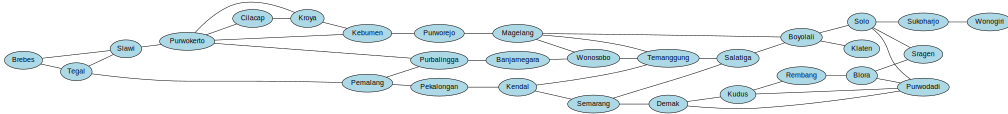

In [3]:
def visualize_jateng(graph_obj, graph_name="", highlight_path=None):
    dot = graphviz.Graph(comment=graph_name)
    dot.attr(rankdir='LR', size='14,10')
    dot.attr('graph', label=graph_name, fontsize='16', fontname='Helvetica')

    nodes_in_graph = set()
    for u, neighbors in graph_obj.graph.items():
        nodes_in_graph.add(str(u))
        for v in neighbors:
            nodes_in_graph.add(str(v))

    for node in sorted(nodes_in_graph):
        dot.node(node, style='filled', fillcolor='lightblue',
                 fontname='Helvetica', shape='ellipse')

    added_edges = set()
    for u, neighbors in graph_obj.graph.items():
        for v in neighbors:
            if (str(v), str(u)) not in added_edges and (str(u), str(v)) not in added_edges:
                dot.edge(str(u), str(v))
                added_edges.add((str(u), str(v)))

    if highlight_path:
        for i in range(len(highlight_path)):
            node = str(highlight_path[i])
            dot.node(node, style='filled',
                     fillcolor='red' if i == 0 else 'lightgreen',
                     fontcolor='white' if i == 0 else 'black')
            if i < len(highlight_path) - 1:
                u = str(highlight_path[i])
                v = str(highlight_path[i + 1])
                dot.edge(u, v, color='red', penwidth='2.5')

    return dot

display(visualize_jateng(jateng_graph))

In [ ]:
import heapq
import collections

class WeightedGraph:
    def __init__(self):
        # Graph disimpan sebagai adjacency list, dengan setiap edge memiliki bobot
        # self.graph[u] = [(v1, weight1), (v2, weight2), ...]
        self.graph = collections.defaultdict(list)
        self.nodes = set()  # Set untuk menyimpan semua node unik dalam graph

    def add_edge(self, u, v, weight):
        # Tambahkan edge dari u ke v dengan bobot
        self.graph[u].append((v, weight))
        self.nodes.add(u)  # Tambahkan u ke set node
        self.nodes.add(v)  # Tambahkan v ke set node

    def dijkstra(self, start_node):
        # Dictionary untuk menyimpan jarak terpendek dari start_node ke setiap node
        distances = {node: float('infinity') for node in self.nodes}
        distances[start_node] = 0

        # Priority queue untuk menyimpan (jarak, node)
        priority_queue = [(0, start_node)]

        # Dictionary untuk menyimpan jalur terpendek (previous node dalam jalur)
        previous_nodes = {}

        while priority_queue:
            current_distance, current_node = heapq.heappop(priority_queue)

            # Jika jarak yang diambil dari queue lebih besar dari jarak yang sudah diketahui,
            # berarti kita sudah menemukan jalur yang lebih pendek sebelumnya, jadi abaikan.
            if current_distance > distances[current_node]:
                continue

            # Jelajahi setiap tetangga dari current_node
            for neighbor, weight in self.graph[current_node]:
                distance = current_distance + weight

                # Jika jarak baru lebih pendek dari jarak yang sudah diketahui ke tetangga
                if distance < distances[neighbor]:
                    distances[neighbor] = distance
                    previous_nodes[neighbor] = current_node
                    heapq.heappush(priority_queue, (distance, neighbor))

        return distances, previous_nodes

    def get_shortest_path(self, start_node, end_node, previous_nodes):
        path = collections.deque()
        current = end_node
        while current is not None:
            path.appendleft(current)
            current = previous_nodes.get(current)
            if current == start_node:
                path.appendleft(current)
                break

        # If current node is not start_node and not in previous_nodes, there is no path
        if current is not None and current not in previous_nodes and current != start_node:
            return []  # No path found

        # Check if start_node is the first element of the path
        if path and path[0] == start_node:
            return list(path)
        else:
            return []  # No path found or start_node is not in path
        
    def add_edge(self, u, v, weight):
        # Tambahkan u -> v
        self.graph[u].append((v, weight))
        # Tambahkan v -> u (Agar bisa jalan dua arah)
        self.graph[v].append((u, weight))
        self.nodes.add(u)
        self.nodes.add(v)


# Membuat instance WeightedGraph
weighted_graph = WeightedGraph()

weighted_graph.add_edge('Brebes', 'Tegal', 12)
weighted_graph.add_edge('Tegal', 'Pemalang', 30)
weighted_graph.add_edge('Pemalang', 'Pekalongan', 35)
weighted_graph.add_edge('Pekalongan', 'Kendal', 65)
weighted_graph.add_edge('Kendal', 'Semarang', 30)
weighted_graph.add_edge('Semarang', 'Demak', 25)
weighted_graph.add_edge('Demak', 'Kudus', 25)
weighted_graph.add_edge('Kudus', 'Rembang', 60)
weighted_graph.add_edge('Rembang', 'Blora', 35)

weighted_graph.add_edge('Brebes', 'Slawi', 20)
weighted_graph.add_edge('Tegal', 'Slawi', 10)
weighted_graph.add_edge('Slawi', 'Purwokerto', 75)

weighted_graph.add_edge('Purwokerto', 'Cilacap', 50)
weighted_graph.add_edge('Purwokerto', 'Kroya', 25)
weighted_graph.add_edge('Cilacap', 'Kroya', 30)
weighted_graph.add_edge('Kroya', 'Kebumen', 45)
weighted_graph.add_edge('Kebumen', 'Purworejo', 30)
weighted_graph.add_edge('Purworejo', 'Magelang', 45)
weighted_graph.add_edge('Purwokerto', 'Kebumen', 100)

weighted_graph.add_edge('Pemalang', 'Purbalingga', 60)
weighted_graph.add_edge('Purwokerto', 'Purbalingga', 20)
weighted_graph.add_edge('Purbalingga', 'Banjarnegara', 30)
weighted_graph.add_edge('Banjarnegara', 'Wonosobo', 30)
weighted_graph.add_edge('Wonosobo', 'Temanggung', 25)
weighted_graph.add_edge('Temanggung', 'Kendal', 45)
weighted_graph.add_edge('Temanggung', 'Salatiga', 45)
weighted_graph.add_edge('Temanggung', 'Magelang', 25)

weighted_graph.add_edge('Semarang', 'Salatiga', 50)
weighted_graph.add_edge('Salatiga', 'Boyolali', 25)
weighted_graph.add_edge('Magelang', 'Boyolali', 35)
weighted_graph.add_edge('Magelang', 'Wonosobo', 65)
weighted_graph.add_edge('Boyolali', 'Klaten', 30)
weighted_graph.add_edge('Boyolali', 'Solo', 25)

weighted_graph.add_edge('Solo', 'Sukoharjo', 10)
weighted_graph.add_edge('Solo', 'Sragen', 30)
weighted_graph.add_edge('Solo', 'Purwodadi', 65)
weighted_graph.add_edge('Sukoharjo', 'Wonogiri', 30)
weighted_graph.add_edge('Sragen', 'Blora', 80)
weighted_graph.add_edge('Purwodadi', 'Demak', 40)
weighted_graph.add_edge('Purwodadi', 'Kudus', 40)
weighted_graph.add_edge('Purwodadi', 'Blora', 65)

start_node_dijkstra = 'Solo'
end_node_dijkstra = 'Kendal'

distances, previous_nodes = weighted_graph.dijkstra('Solo')
path = weighted_graph.get_shortest_path('Solo', 'Kendal', previous_nodes)

print(f"Jarak Terpendek: {distances['Kendal']} km")
print(f"Jalur yang dilewati: {' -> '.join(path)}")


Jarak Terpendek: 130 km
Jalur yang dilewati: Solo -> Boyolali -> Magelang -> Temanggung -> Kendal
